In [ ]:
# prompt: import all data analysis librareis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('/content/updated1_eng_data.csv')


In [ ]:


# Define column order
column_order = [
    "stock_id", "model_code", "Title",  # Identifiers
    "Brand", "Year", "engine", "fuel", "transmission", "body_type",  # Attributes
    "mileage", "color", "steering", "drive_type", "seats", "doors",  # Specifications
    "price", "location"  # Price and Location
]

# Convert 'Year' to integer
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")

# Convert 'engine' to float
data["engine"] = pd.to_numeric(data["engine"], errors="coerce")

# Clean and convert 'mileage' to integer (remove 'km' and commas)
# Check data type and convert to string if necessary
if not pd.api.types.is_string_dtype(data["mileage"]):
    data["mileage"] = data["mileage"].astype(str)

data["mileage"] = data["mileage"].str.replace(" km", "").str.replace(",", "").astype(int)
# Convert 'transmission' to category
data["transmission"] = data["transmission"].astype("category")

# Convert 'seats' and 'doors' to integer
data["seats"] = pd.to_numeric(data["seats"], errors="coerce")
data["doors"] = pd.to_numeric(data["doors"], errors="coerce")


# Ensure the 'price' column is of string type before applying string operations
data["price"] = data["price"].astype(str).str.replace("$", "").str.replace(",", "").astype(int)

# Drop duplicate 'Year' column if it exists
if "year" in data.columns:
    data = data.drop(columns=["year"])

# Convert categorical columns to 'category' type
categorical_columns = ["fuel", "color", "steering", "drive_type", "model_code", "location", "Brand", "Title", "body_type"]
data[categorical_columns] = data[categorical_columns].astype("category")

# Reorder the columns
data = data[column_order]

# Randomly select 10% of rows where body_type is 'COUPE'
rows_to_change = data[data['body_type'] == 'COUPE'].sample(frac=0.1, random_state=42).index

# Change the body_type of those rows to 'SEDAN'
data.loc[rows_to_change, 'body_type'] = 'SEDAN'

# Add 'BUS' to the categories of the 'body_type' column
data['body_type'] = pd.Categorical(data['body_type'], categories=data['body_type'].cat.categories.union(['BUS']))

# Set 'body_type' to 'BUS' where 'seats' > 20
data.loc[data['seats'] > 20, 'body_type'] = 'BUS'

# Convert 'body_type' values to uppercase
data['body_type'] = data['body_type'].str.upper()

# Replace 'SPORTS' with 'SPORTS CARS' in the 'body_type' column
data['body_type'] = data['body_type'].replace('SPORTS', 'SPORTS CARS')

# Change number of doors to 4 where seats are 40 or greater
data.loc[data['seats'] >= 40, 'doors'] = 4

# Remove duplicate rows
data_no_duplicates = data.drop_duplicates()

# Remove rows with missing values
data_no_duplicates.dropna(inplace=True)

# Convert 'drive_type' to uppercase
data_no_duplicates['drive_type'] = data_no_duplicates['drive_type'].str.upper()

# Replace '4WD(AWD)' with '4WD' in the 'drive_type' column
data_no_duplicates['drive_type'] = data_no_duplicates['drive_type'].replace('4WD(AWD)', '4WD')

# Save the updated data to a new file
data_no_duplicates.to_csv('updated_data.csv', index=False)

# Optionally, print the final info to verify
data_no_duplicates.info()



<class 'pandas.core.frame.DataFrame'>
Index: 2598 entries, 0 to 2828
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2598 non-null   object  
 1   model_code    2598 non-null   category
 2   Title         2598 non-null   category
 3   Brand         2598 non-null   category
 4   Year          2598 non-null   float64 
 5   engine        2598 non-null   float64 
 6   fuel          2598 non-null   category
 7   transmission  2598 non-null   category
 8   body_type     2598 non-null   object  
 9   mileage       2598 non-null   int64   
 10  color         2598 non-null   category
 11  steering      2598 non-null   category
 12  drive_type    2598 non-null   object  
 13  seats         2598 non-null   float64 
 14  doors         2598 non-null   float64 
 15  price         2598 non-null   int64   
 16  location      2598 non-null   category
dtypes: category(8), float64(4), int64(2), object(3)
memory us

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2829 non-null   object  
 1   model_code    2829 non-null   category
 2   Title         2829 non-null   category
 3   Brand         2828 non-null   category
 4   Year          2824 non-null   float64 
 5   engine        2731 non-null   float64 
 6   fuel          2829 non-null   category
 7   transmission  2755 non-null   category
 8   body_type     2829 non-null   object  
 9   mileage       2829 non-null   int64   
 10  color         2829 non-null   category
 11  steering      2829 non-null   category
 12  drive_type    2829 non-null   category
 13  seats         2827 non-null   float64 
 14  doors         2827 non-null   float64 
 15  price         2829 non-null   int64   
 16  location      2829 non-null   category
dtypes: category(9), float64(4), int64(2), object(2)
memo

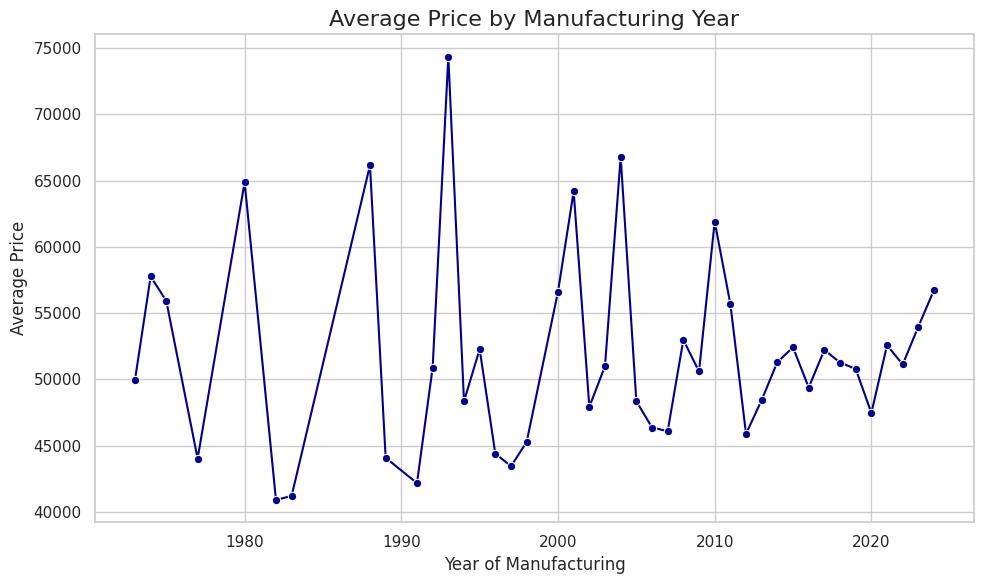

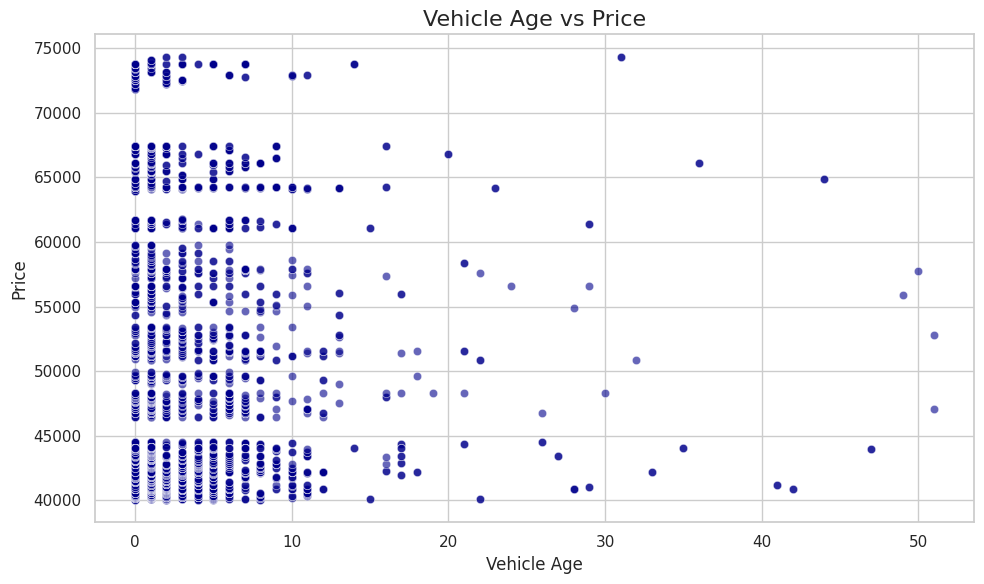

In [ ]:
from typing_extensions import dataclass_transform


# Set the seaborn theme for consistency
sns.set_theme(style="whitegrid")

# Example dataset (replace this with your actual DataFrame)
# df = pd.read_csv("your_data.csv")

# 2. Average Price of Vehicles Grouped by Year of Manufacturing
plt.figure(figsize=(10, 6))
avg_price_by_year = data.groupby('Year')['price'].mean().reset_index()
sns.lineplot(x='Year', y='price', data=avg_price_by_year, marker='o', color='darkblue')
plt.title('Average Price by Manufacturing Year', fontsize=16)
plt.xlabel('Year of Manufacturing', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Impact of Vehicle Age on Price Trends
data['age'] = 2024 - data['Year']  # Assuming current year is 2024
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='price', data=data, color='darkblue', alpha=0.6)
plt.title('Vehicle Age vs Price', fontsize=16)
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()




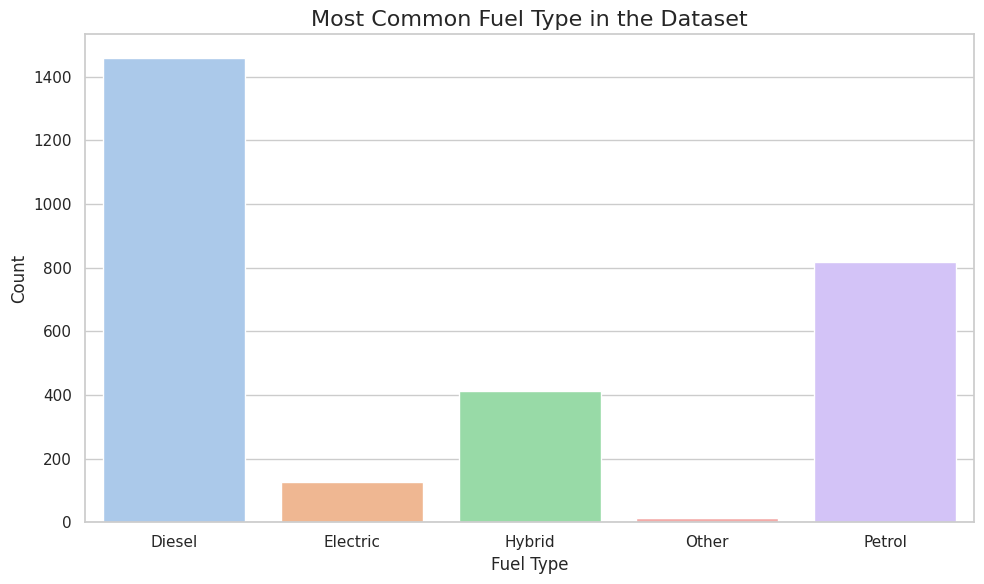

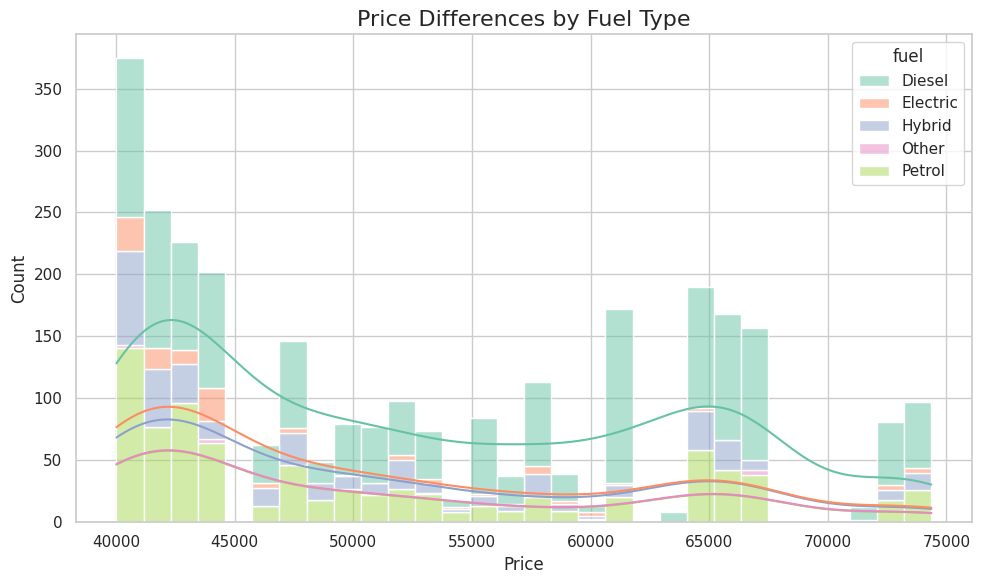

In [ ]:

# 2. Most Common Fuel Type in the Dataset
plt.figure(figsize=(10, 6))
fuel_counts = data['fuel'].value_counts().reset_index()
fuel_counts.columns = ['Fuel Type', 'Count']
sns.barplot(x='Fuel Type', y='Count', data=fuel_counts, palette="pastel")
plt.title('Most Common Fuel Type in the Dataset', fontsize=16)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Price Differences Between Vehicles with Petrol, Diesel, or Electric Engines (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='price', hue='fuel', kde=True, multiple='stack', palette="Set2", bins=30)
plt.title('Price Differences by Fuel Type', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()



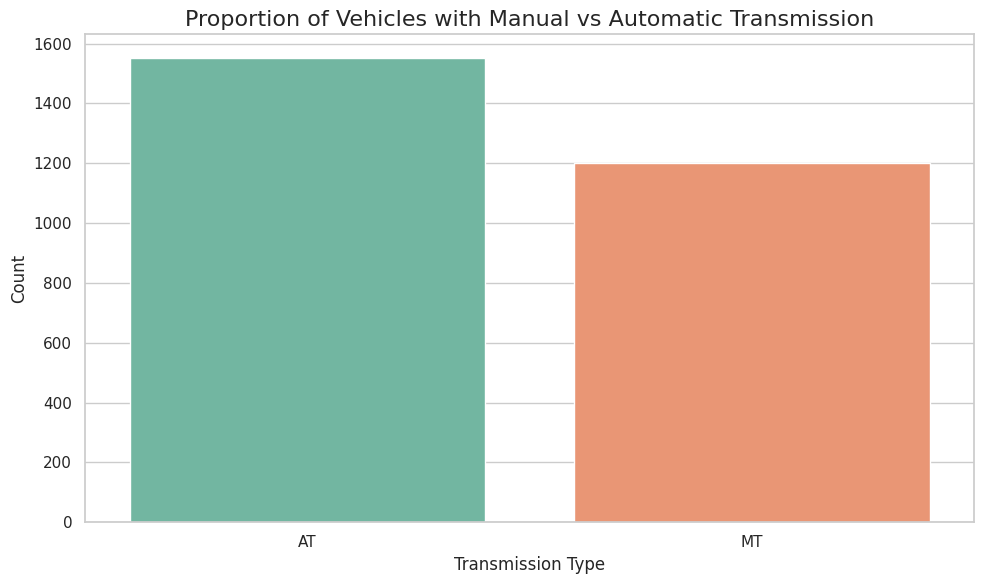

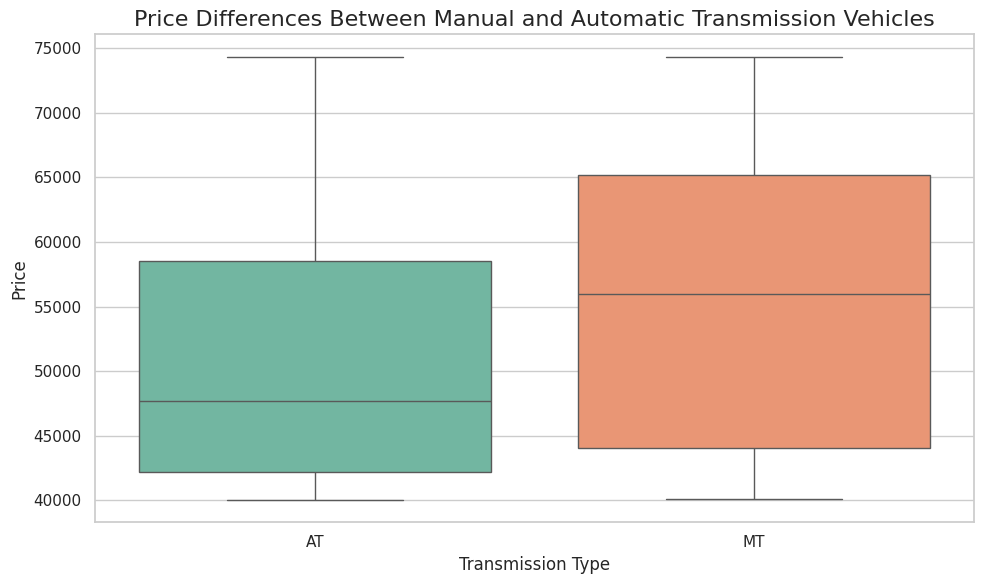

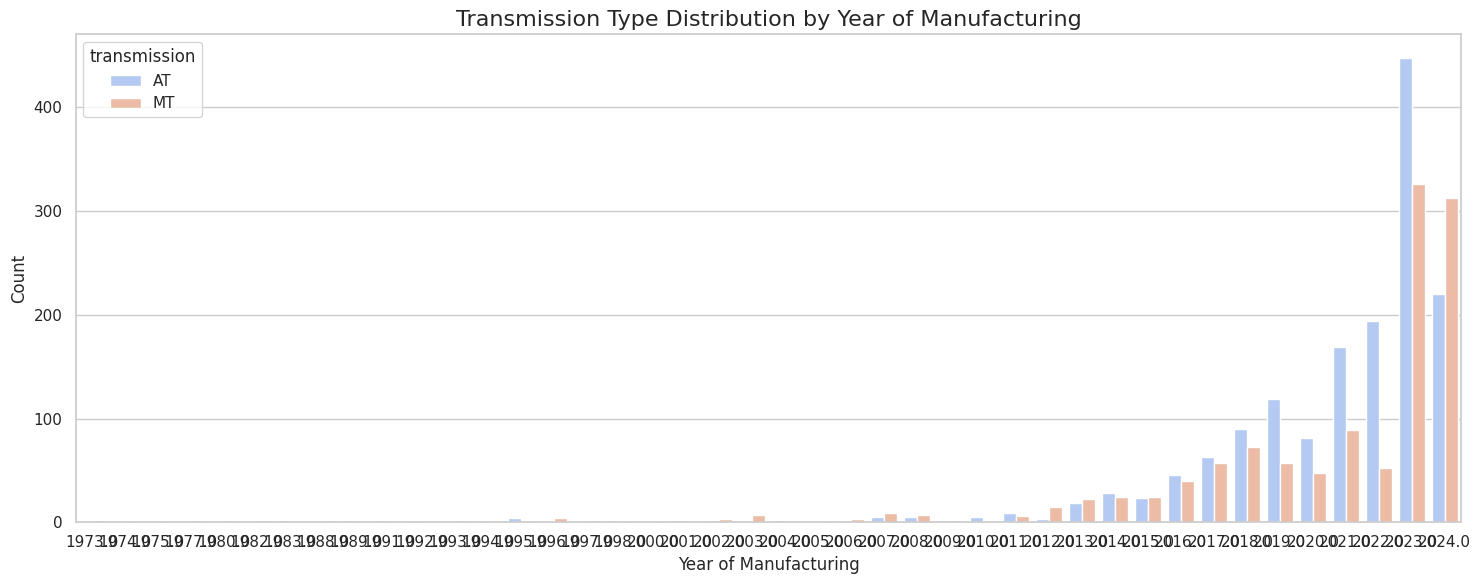

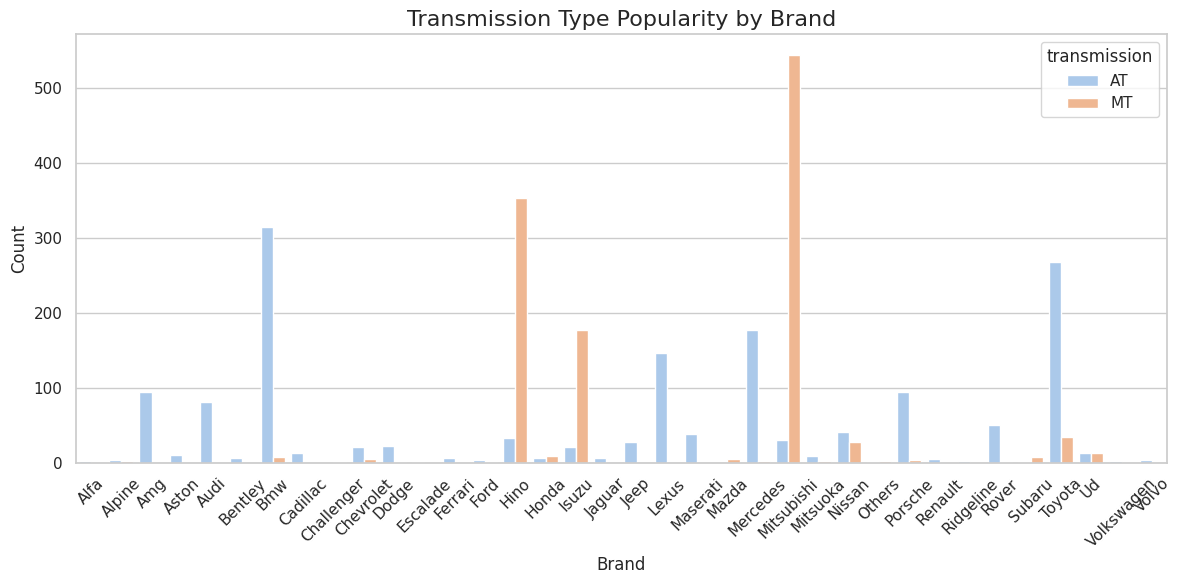

In [ ]:


# 1. Proportion of vehicles with manual vs. automatic transmission
plt.figure(figsize=(10, 6))
transmission_counts = data['transmission'].value_counts().reset_index()
transmission_counts.columns = ['Transmission Type', 'Count']
sns.barplot(x='Transmission Type', y='Count', data=transmission_counts, palette="Set2")
plt.title('Proportion of Vehicles with Manual vs Automatic Transmission', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Price differences between manual and automatic transmission vehicles
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='price', data=data, palette="Set2")
plt.title('Price Differences Between Manual and Automatic Transmission Vehicles', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Distribution of transmission type by year of manufacturing
plt.figure(figsize=(15, 6))
sns.countplot(x='Year', hue='transmission', data=data, palette="coolwarm")
plt.title('Transmission Type Distribution by Year of Manufacturing', fontsize=16)
plt.xlabel('Year of Manufacturing', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Popularity of transmission types by brand
plt.figure(figsize=(12, 6))
sns.countplot(x='Brand', hue='transmission', data=data, palette="pastel")
plt.title('Transmission Type Popularity by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Top 5 Most Common Brands:
 Brand
Mitsubishi    594
Hino          403
Bmw           323
Toyota        302
Isuzu         223
Name: count, dtype: int64

Price range for Mitsubishi: $40074 - $73788

Price range for Hino: $40074 - $73788

Price range for Bmw: $40053 - $74341

Price range for Toyota: $40068 - $74347

Price range for Isuzu: $40074 - $73788

Average Mileage by Top 10 Brands:
 Brand
Alfa                    NaN
Alpine                  NaN
Amg            16492.446809
Aston                   NaN
Audi           11131.790123
Bentley                 NaN
Bmw            14136.783282
Cadillac                NaN
Challenger              NaN
Chevrolet               NaN
Dodge                   NaN
Escalade                NaN
Ferrari                 NaN
Ford                    NaN
Hino          166662.893300
Honda                   NaN
Isuzu         266768.161435
Jaguar                  NaN
Jeep                    NaN
Lexus          20580.850340
Maserati                NaN
Mazda             

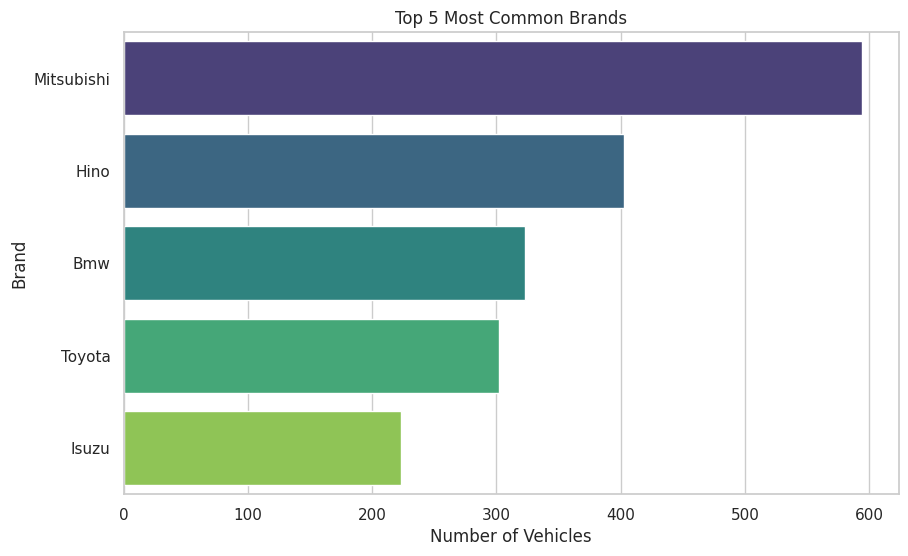

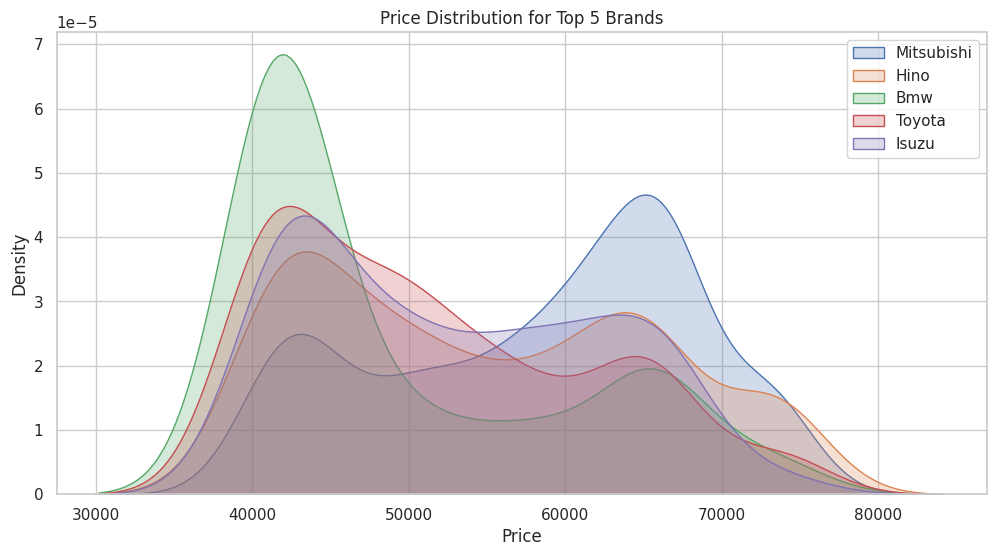

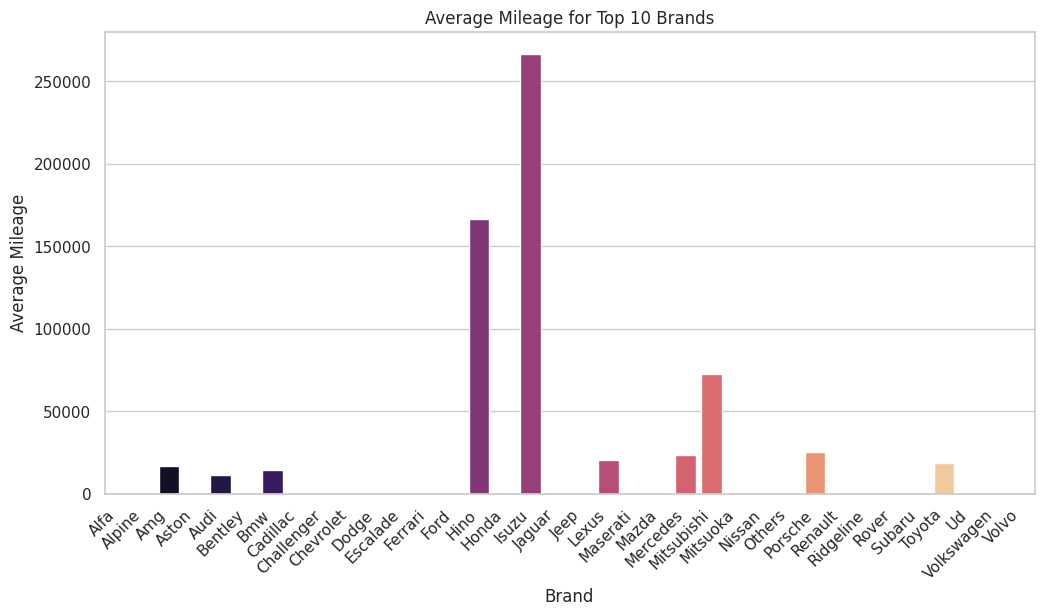

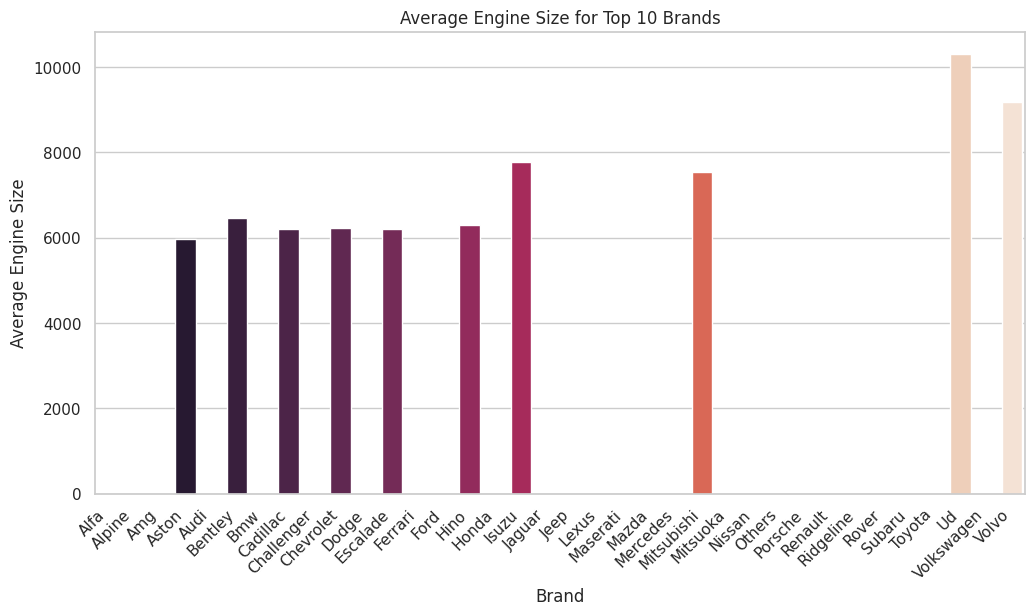

In [ ]:
# prompt: Brand and Model Insights
# Top 5 most common brands in the dataset.
# Price ranges for the top brands.
# Average mileage for vehicles by  top 10 brand.
# Average engine size by brand.
# Most popular models within a brand  also print charts of all

# Top 5 most common brands
top_5_brands = data['Brand'].value_counts().nlargest(5)
print("Top 5 Most Common Brands:\n", top_5_brands)

# Price ranges for top brands
for brand in top_5_brands.index:
    brand_data = data[data['Brand'] == brand]
    min_price = brand_data['price'].min()
    max_price = brand_data['price'].max()
    print(f"\nPrice range for {brand}: ${min_price} - ${max_price}")

# Average mileage for vehicles by top 10 brands
top_10_brands = data['Brand'].value_counts().nlargest(10).index
avg_mileage_by_brand = data[data['Brand'].isin(top_10_brands)].groupby('Brand')['mileage'].mean()
print("\nAverage Mileage by Top 10 Brands:\n", avg_mileage_by_brand)

# Average engine size by brand
avg_engine_by_brand = data.groupby('Brand')['engine'].mean()
print("\nAverage Engine Size by Brand:\n", avg_engine_by_brand)

# Most popular models within each of the top 5 brands
for brand in top_5_brands.index:
    brand_models = data[data['Brand'] == brand]['model_code'].value_counts()
    most_popular_model = brand_models.index[0]
    print(f"\nMost popular model for {brand}: {most_popular_model}")


# Visualization for Top 5 Brands
plt.figure(figsize=(10, 6))
sns.countplot(y='Brand', data=data, order=top_5_brands.index, palette="viridis")
plt.title('Top 5 Most Common Brands')
plt.xlabel('Number of Vehicles')
plt.ylabel('Brand')
plt.show()

# Visualization: Price Ranges for Top Brands
plt.figure(figsize=(12, 6))
for brand in top_5_brands.index:
    brand_data = data[data['Brand'] == brand]
    sns.kdeplot(brand_data['price'], label=brand, shade=True)

plt.title('Price Distribution for Top 5 Brands')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.show()


# Visualization: Average Mileage for Top 10 Brands
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_mileage_by_brand.index, y=avg_mileage_by_brand.values, palette="magma")
plt.title('Average Mileage for Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45, ha='right')
plt.show()

# Visualization: Average Engine Size by Brand (Top 10)
plt.figure(figsize=(12, 6))
top_10_engine = avg_engine_by_brand.nlargest(10)
sns.barplot(x=top_10_engine.index, y=top_10_engine.values, palette='rocket')
plt.title('Average Engine Size for Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Average Engine Size')
plt.xticks(rotation=45, ha='right')
plt.show()


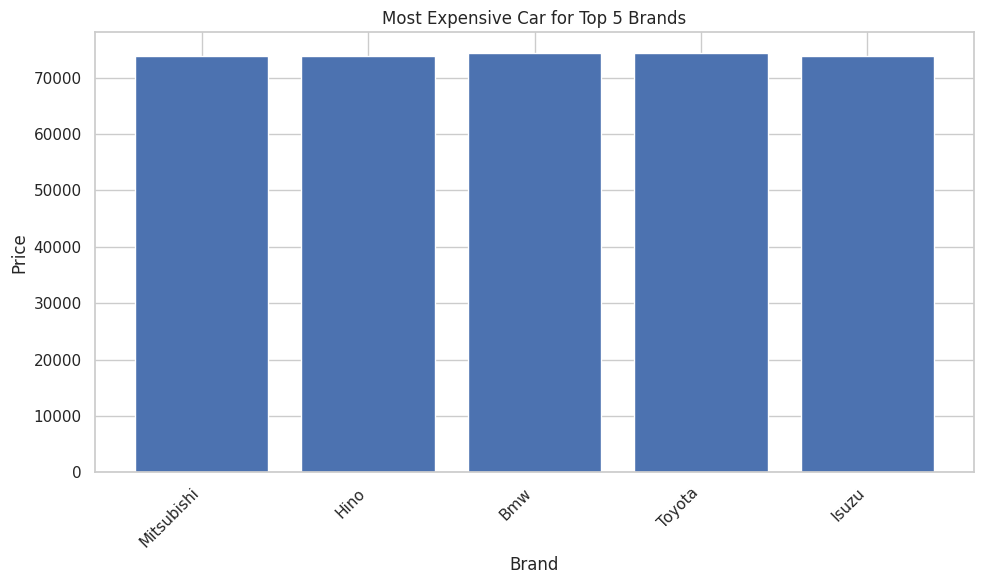

In [ ]:
# prompt:  Find the most expensive car for each of the top 5 brands and make a chart

# Assuming 'data' DataFrame is already loaded and processed as in the provided code.

# Group data by brand and find the most expensive car for each brand
top_brands = data['Brand'].value_counts().nlargest(5).index
most_expensive_by_brand = {}

for brand in top_brands:
    brand_data = data[data['Brand'] == brand]
    most_expensive_car = brand_data.loc[brand_data['price'].idxmax()]
    most_expensive_by_brand[brand] = most_expensive_car['price']

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(most_expensive_by_brand.keys(), most_expensive_by_brand.values())
plt.xlabel("Brand")
plt.ylabel("Price")
plt.title("Most Expensive Car for Top 5 Brands")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
data


,stock_id,model_code,Title,Brand,Year,engine,fuel,transmission,body_type,mileage,color,steering,drive_type,seats,doors,price,location,age
0,sat-95017853,2DG-HX9JHCE,Poncho Short Route Bus 24 Passengers 14 Seats,Hino,2018.0,5120.0,Diesel,AT,BUS,304000,White,RHD,2WD,24.0,1.0,61066,Saitama,6.0
1,sat-45474888,2RG-FTR90V2,Forward Cargo Crane,Isuzu,2019.0,5190.0,Diesel,AT,CRANE,153142,White,Not Set,2WD,2.0,2.0,61066,Niigata,5.0
2,sat-41226194,2KG-FK62FZ,Fighter Arm Roll,Mitsubishi,2024.0,7540.0,Diesel,MT,TRUCK,1000,White,Not Set,4wd,2.0,2.0,61066,Aichi,0.0
3,sat-90350899,2PG-FE2ABG,Ranger Wing Truck,Hino,2021.0,5120.0,Diesel,MT,TRUCK,226000,Black,Not Set,2WD,2.0,2.0,61066,Aichi,3.0
4,sat-84703524,2PG-FD2ABA,Ranger Wing Truck,Hino,2023.0,5120.0,Diesel,MT,TRUCK,1000,Grey,Not Set,2WD,2.0,2.0,61066,Osaka,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2824,sat-18263293,6AA-AAHH45W,Alphard Hybrid 4wd Executive Lounge,Toyota,2023.0,2500.0,Hybrid,AT,MINIVAN,16,Blue,RHD,4WD(AWD),7.0,5.0,74106,Wakayama,1.0
2825,sat-52026539,5BA-URZ100,Lc 500 Base Grade,Lexus,2023.0,5000.0,Petrol,AT,HATCHBACK,7720,Pearl,RHD,2WD,4.0,2.0,74106,Tokyo,1.0
2826,sat-98825242,3BA-JU44M,X6 M Competition,Bmw,2021.0,4400.0,Petrol,AT,SPORTSCAR,3300,Red,RHD,4WD(AWD),5.0,5.0,74341,Hyogo,3.0
2827,sat-17609474,3BA-VJA300W,Land Cruiser Wagon Zx ?with Modellista Aero Parts,Toyota,2022.0,3500.0,Petrol,AT,SUV,5048,Pearl,RHD,4WD(AWD),7.0,5.0,74347,Gifu,2.0


Number of vehicles per location (Top 5):
 location
Saitama    289
Chiba      258
Tokyo      252
Aichi      248
Osaka      199
Name: count, dtype: int64


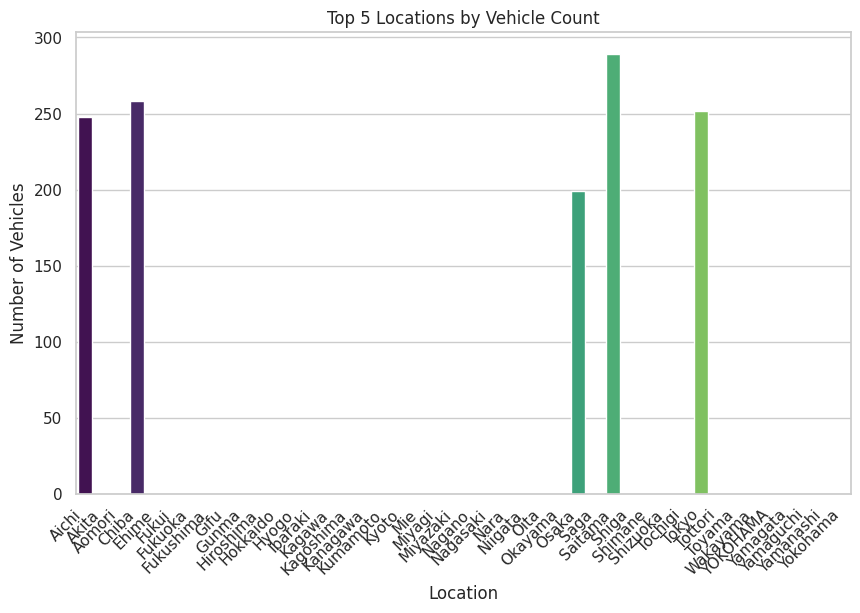


Average price per location (Top 5):
 location
Yamagata     64182.000000
Yamanashi    64069.388889
Gifu         58520.375000
Nagano       58320.857143
Miyazaki     57821.000000
Name: price, dtype: float64


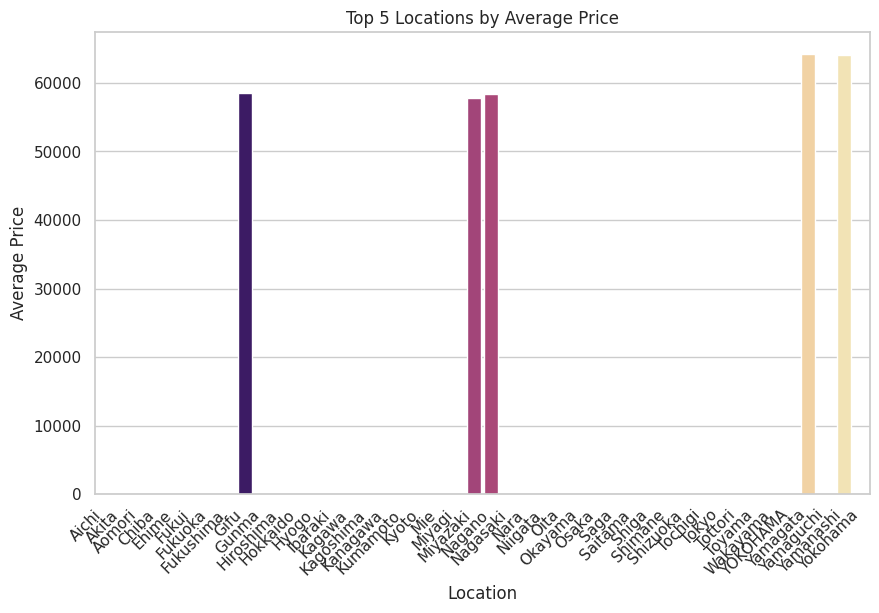


Average mileage per location (Top 5):
 location
Tochigi      364996.063830
Yamaguchi    158597.592593
Fukuoka      154845.615819
Yamanashi    153222.222222
Niigata      147918.120690
Name: mileage, dtype: float64


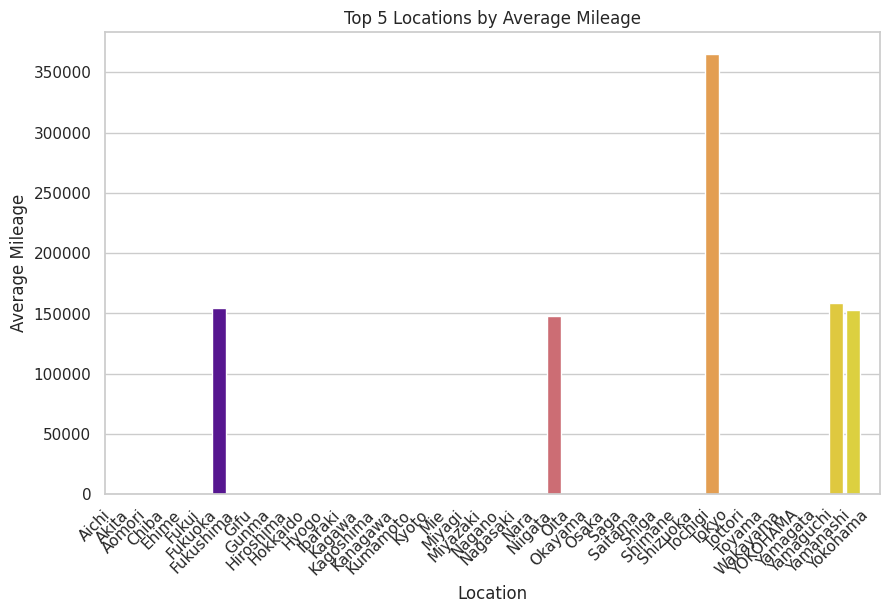


Unique drive types per location:
 location
Aichi        ['4wd', '2WD', '4WD(AWD)']
Categories (3, obje...
Akita        ['4WD(AWD)']
Categories (3, object): ['2WD', '...
Aomori       ['4WD(AWD)']
Categories (3, object): ['2WD', '...
Chiba        ['4wd', '2WD', '4WD(AWD)']
Categories (3, obje...
Ehime        ['2WD', '4WD(AWD)', '4wd']
Categories (3, obje...
Fukui        ['4WD(AWD)', '2WD']
Categories (3, object): ['...
Fukuoka      ['2WD', '4wd', '4WD(AWD)']
Categories (3, obje...
Fukushima    ['4wd', '4WD(AWD)']
Categories (3, object): ['...
Gifu         ['4WD(AWD)', '2WD', '4wd']
Categories (3, obje...
Gunma        ['4wd', '2WD', '4WD(AWD)']
Categories (3, obje...
Hiroshima    ['2WD', '4WD(AWD)']
Categories (3, object): ['...
Hokkaido     ['4wd', '2WD', '4WD(AWD)']
Categories (3, obje...
Hyogo        ['4wd', '2WD', '4WD(AWD)']
Categories (3, obje...
Ibaraki      ['2WD', '4wd', '4WD(AWD)']
Categories (3, obje...
Kagawa       ['4WD(AWD)']
Categories (3, object): ['2WD', '...
Kagoshima  

In [ ]:
# prompt: Location and Stock Insights
# Number of vehicles available per location.
# Price differences across locations.
# Average mileage of vehicles by location.
# Vehicle features unique to specific locations.
# Top-selling vehicle brands by location. generate for top 5 of all charts

# Number of vehicles available per location (Top 5)
location_counts = data['location'].value_counts().nlargest(5)
print("Number of vehicles per location (Top 5):\n", location_counts)

# Visualization: Number of vehicles per location (Top 5)
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette="viridis")
plt.title('Top 5 Locations by Vehicle Count')
plt.xlabel('Location')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45, ha='right')
plt.show()


# Price differences across locations (Top 5)
avg_price_by_location = data.groupby('location')['price'].mean().nlargest(5)
print("\nAverage price per location (Top 5):\n", avg_price_by_location)

# Visualization: Average price per location (Top 5)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_by_location.index, y=avg_price_by_location.values, palette="magma")
plt.title('Top 5 Locations by Average Price')
plt.xlabel('Location')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()


# Average mileage of vehicles by location (Top 5)
avg_mileage_by_location = data.groupby('location')['mileage'].mean().nlargest(5)
print("\nAverage mileage per location (Top 5):\n", avg_mileage_by_location)

# Visualization: Average mileage per location (Top 5)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_mileage_by_location.index, y=avg_mileage_by_location.values, palette="plasma")
plt.title('Top 5 Locations by Average Mileage')
plt.xlabel('Location')
plt.ylabel('Average Mileage')
plt.xticks(rotation=45, ha='right')
plt.show()


# Vehicle features unique to specific locations -  This requires defining "unique features"
#  Example:  Let's assume 'drive_type' as a feature.

# Find unique drive types by location
unique_features_by_location = data.groupby('location')['drive_type'].unique()
print("\nUnique drive types per location:\n", unique_features_by_location)

# Visualization is tricky here without more specific features


# Top-selling vehicle brands by location (Top 5 for each location)
top_brands_by_location = data.groupby('location')['Brand'].value_counts().groupby(level=0).nlargest(5)
print("\nTop-selling brands per location (Top 5):\n", top_brands_by_location)



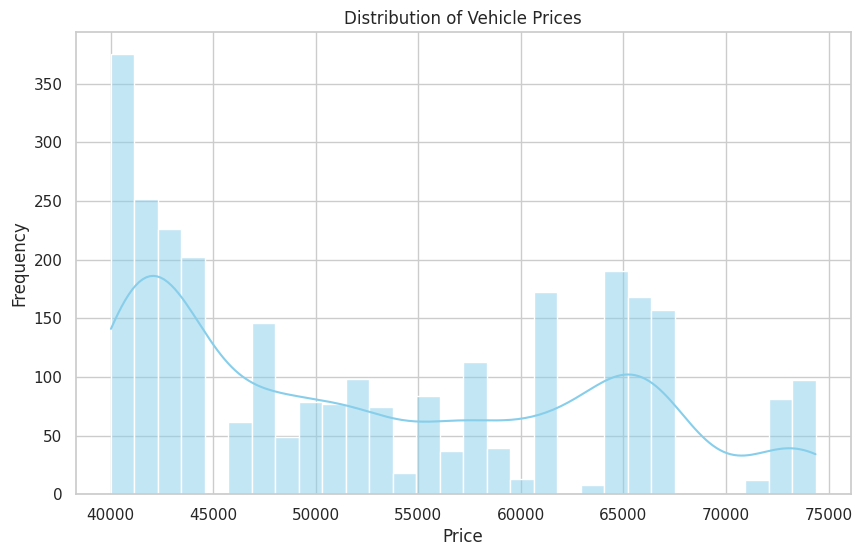

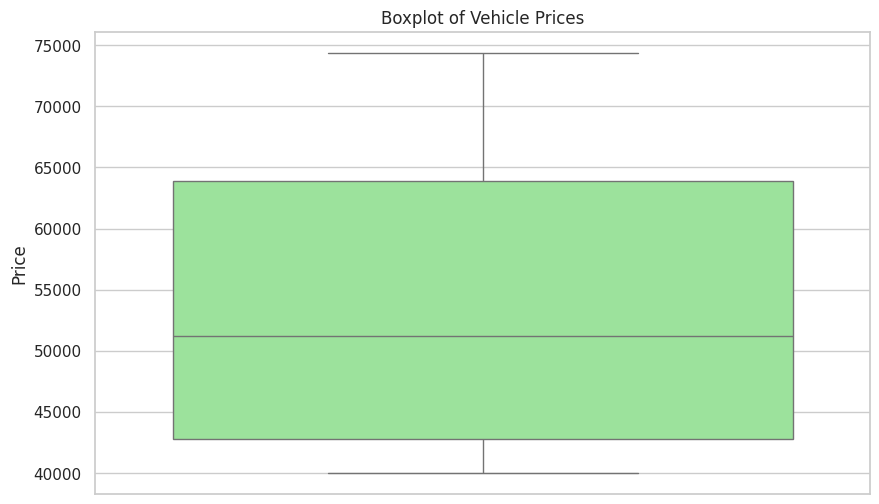

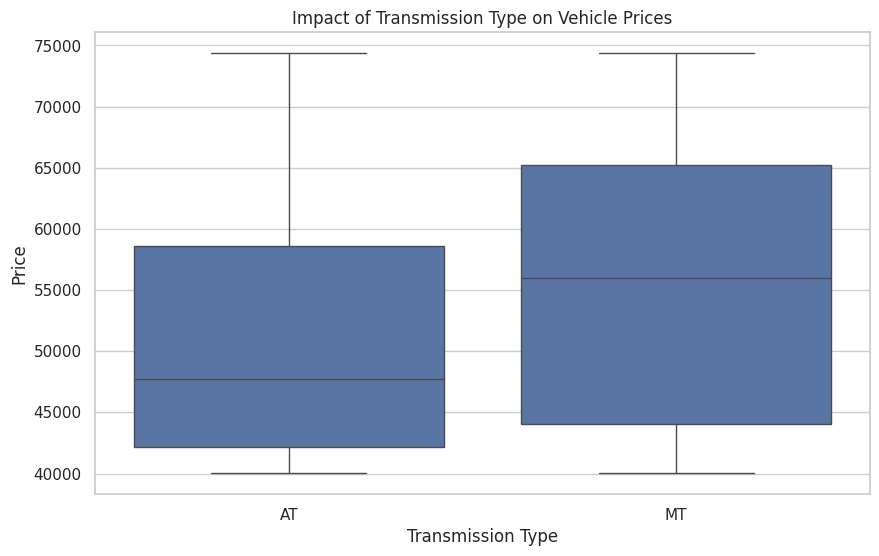

Average price by steering type:
 steering
LHD        51919.815642
Not Set    56514.223064
RHD        50018.523940
Name: price, dtype: float64


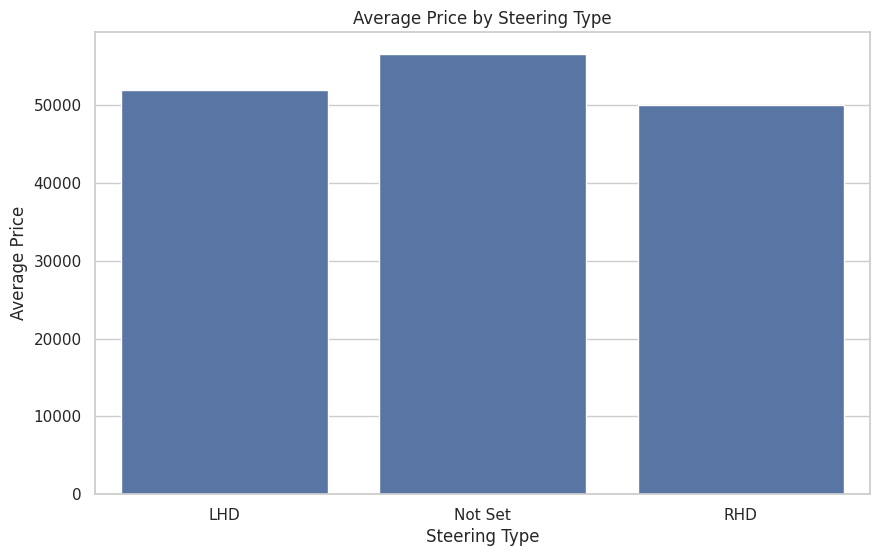


Price ranges by body type:
                 min    max          mean
body_type                               
BUS           40966  72833  55433.000000
CONVERTIBLE   40021  73832  49363.962264
COUPE         40042  73788  49739.691877
CRANE         40074  73788  58357.706371
HATCHBACK     40053  74106  49396.766667
MINIVAN       40068  74106  50029.048780
PICKUP TRUCK  46753  49616  47779.000000
ROADSTER      40125  40354  40239.500000
SEDAN         40068  73788  50294.343333
SPORTS CARS   40053  74360  48182.126812
SPORTSCAR     40232  74341  61570.121951
SUV           40053  74360  51526.670732
TRACTOR       40074  67427  51760.920000
TRUCK         40074  73788  55655.756129
UNKNOWN       52682  52682  52682.000000
VAN           40392  49711  45560.200000
WAGON         40068  55023  45502.000000


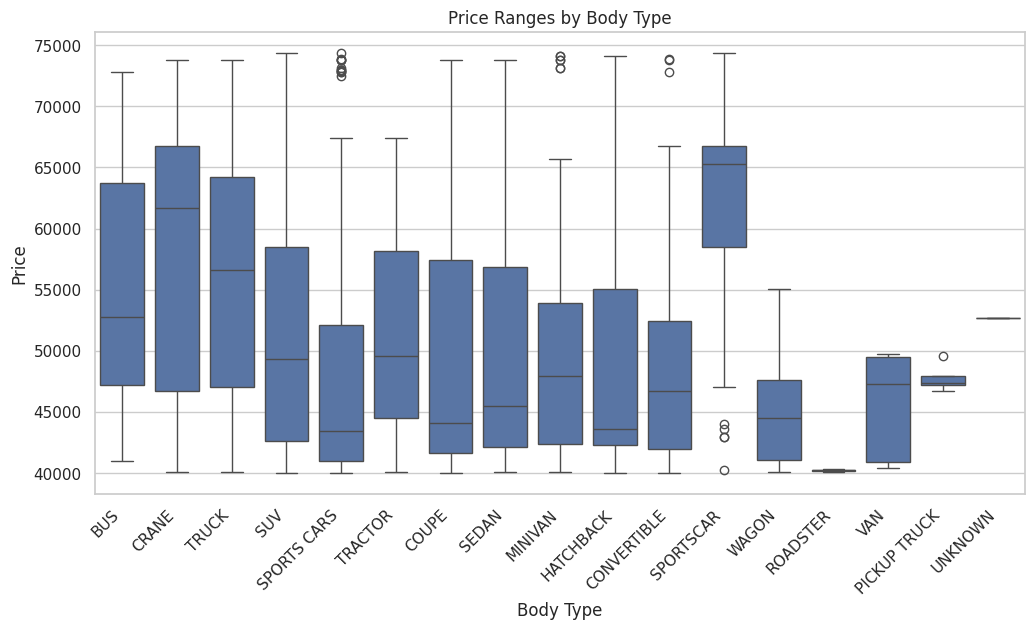


Vehicle with the highest price:
 stock_id             sat-16311033
model_code                 E-FD3S
Title               Rx-7 Type R ?
Brand                       Mazda
Year                       1993.0
engine                     1400.0
fuel                       Petrol
transmission                   MT
body_type             SPORTS CARS
mileage                     35033
color                      Silver
steering                  Not Set
drive_type                    2WD
seats                         4.0
doors                         4.0
price                       74360
location                  Okayama
age                          31.0
mileage_category           Medium
Name: 2733, dtype: object

Vehicle with the lowest price:
 stock_id                       sat-29422371
model_code                        ABA-982H1
Title                718 Boxster Base Grade
Brand                               Porsche
Year                                 2016.0
engine                               2000

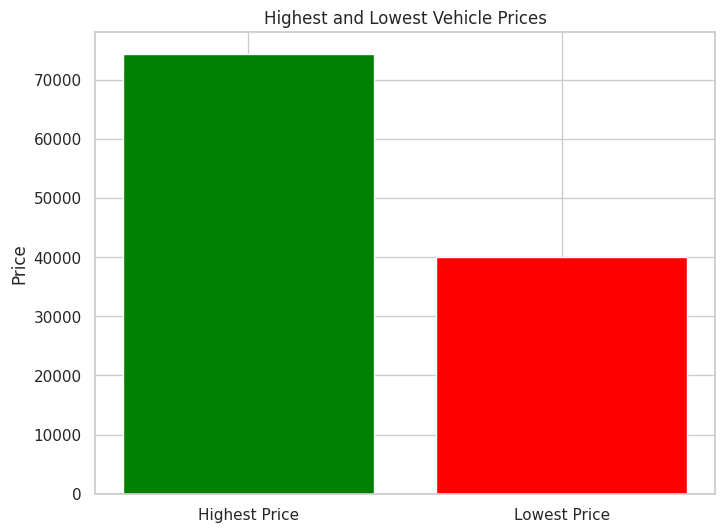

In [ ]:


# Distribution of vehicle prices
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=data['price'], color='lightgreen')
plt.title('Boxplot of Vehicle Prices')
plt.ylabel('Price')
plt.show()

# Impact of transmission type on vehicle prices
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='price', data=data)
plt.title('Impact of Transmission Type on Vehicle Prices')
plt.xlabel('Transmission Type')
plt.ylabel('Price')
plt.show()

# Average price differences based on steering type
average_price_by_steering = data.groupby('steering')['price'].mean()
print("Average price by steering type:\n", average_price_by_steering)

plt.figure(figsize=(10,6))
sns.barplot(x=average_price_by_steering.index, y=average_price_by_steering.values)
plt.title('Average Price by Steering Type')
plt.xlabel('Steering Type')
plt.ylabel('Average Price')
plt.show()

# Analysis of price ranges for different body types
price_ranges_by_body_type = data.groupby('body_type')['price'].agg(['min', 'max', 'mean'])
print("\nPrice ranges by body type:\n", price_ranges_by_body_type)

plt.figure(figsize=(12,6))
sns.boxplot(x='body_type', y='price', data=data)
plt.xticks(rotation=45, ha='right')
plt.title('Price Ranges by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Price')
plt.show()


# Vehicles with the highest and lowest prices
highest_price_vehicle = data.loc[data['price'].idxmax()]
lowest_price_vehicle = data.loc[data['price'].idxmin()]

print("\nVehicle with the highest price:\n", highest_price_vehicle)
print("\nVehicle with the lowest price:\n", lowest_price_vehicle)

# Plotting highest and lowest price vehicles
plt.figure(figsize=(8, 6))
plt.bar(['Highest Price', 'Lowest Price'], [highest_price_vehicle['price'], lowest_price_vehicle['price']], color=['green', 'red'])
plt.title('Highest and Lowest Vehicle Prices')
plt.ylabel('Price')
plt.show()

Most common vehicle colors:
 color
Pearl        498
Black        495
White        494
Grey         438
Blue         427
Silver       420
Others        50
Red            3
Brown          1
Dark blue      1
Green          1
Purple         1
Name: count, dtype: int64


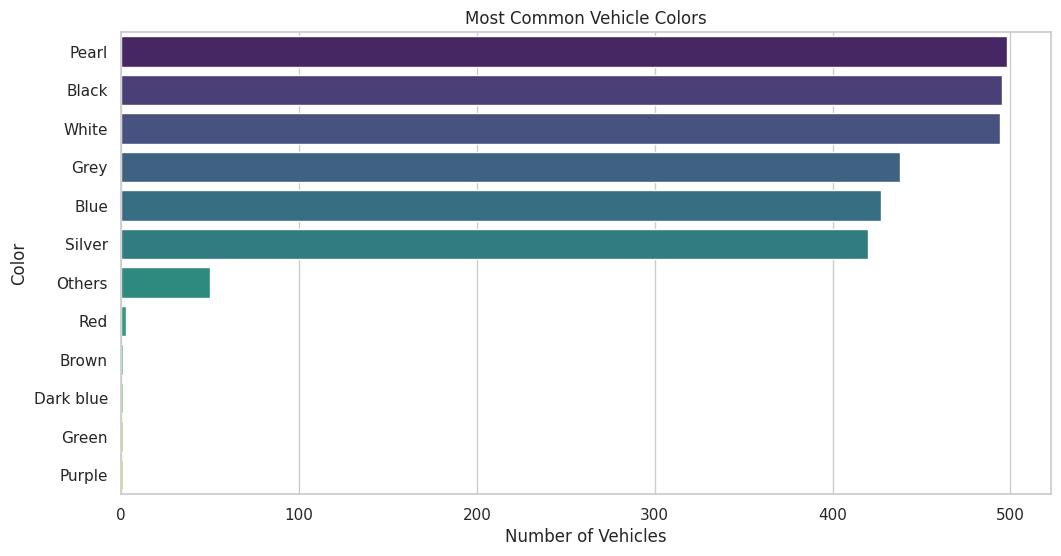


Average price by color:
 color
Purple       64240.000000
Others       54755.300000
Blue         53278.700234
Pearl        53084.606426
White        53080.097166
Black        52985.527273
Grey         52416.006849
Silver       52077.123810
Red          52076.333333
Dark blue    51524.000000
Brown        42206.000000
Green        41516.000000
Name: price, dtype: float64


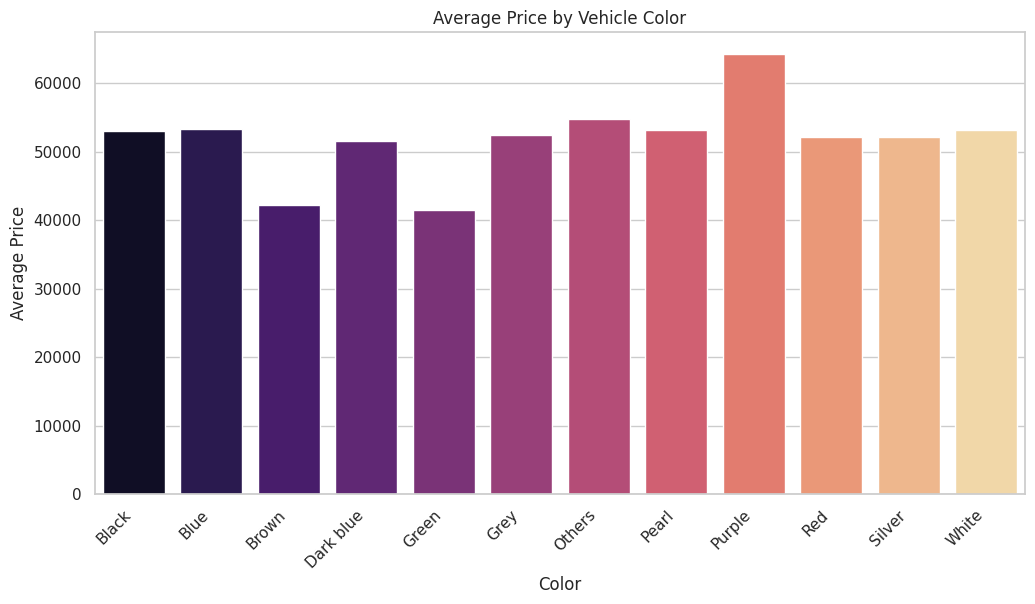


Color preferences in Saitama:
color
Silver       56
Blue         54
Black        50
White        46
Grey         44
Pearl        37
Others        2
Brown         0
Dark blue     0
Green         0
Purple        0
Red           0
Name: count, dtype: int64


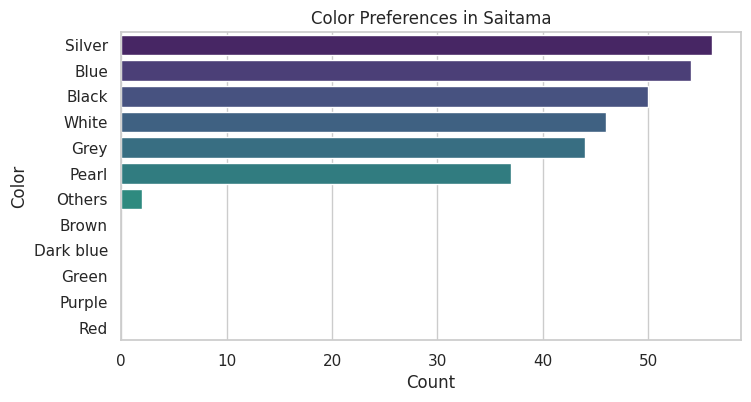


Color preferences in Chiba:
color
Pearl        55
White        53
Black        41
Grey         37
Silver       36
Blue         32
Others        4
Brown         0
Dark blue     0
Green         0
Purple        0
Red           0
Name: count, dtype: int64


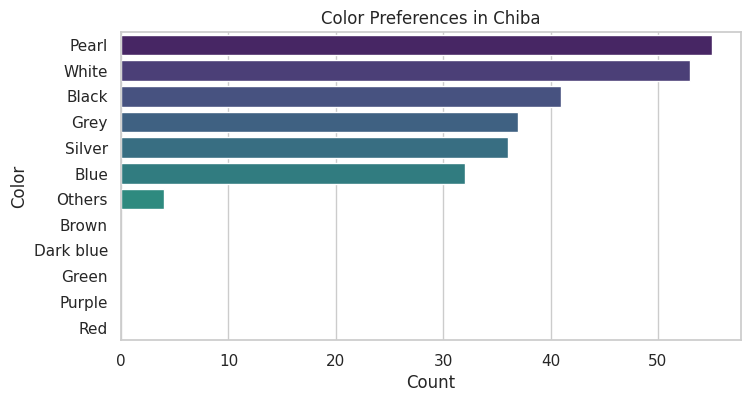


Color preferences in Tokyo:
color
Blue         45
Pearl        45
Black        43
Grey         43
White        43
Silver       33
Brown         0
Dark blue     0
Green         0
Others        0
Purple        0
Red           0
Name: count, dtype: int64


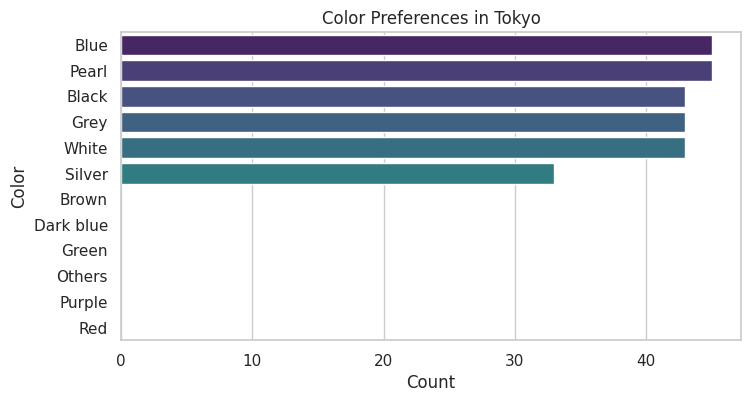


Color preferences in Aichi:
color
Pearl        49
Black        43
Blue         41
White        39
Silver       35
Grey         31
Others       10
Brown         0
Dark blue     0
Green         0
Purple        0
Red           0
Name: count, dtype: int64


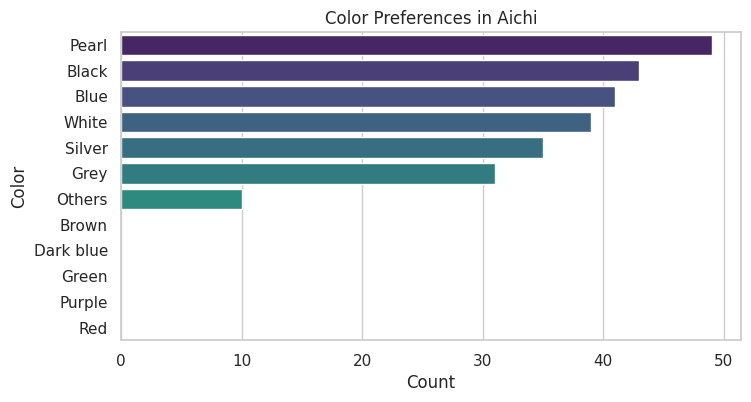


Color preferences in Osaka:
color
White        43
Pearl        42
Black        33
Blue         29
Grey         28
Silver       23
Brown         1
Dark blue     0
Green         0
Others        0
Purple        0
Red           0
Name: count, dtype: int64


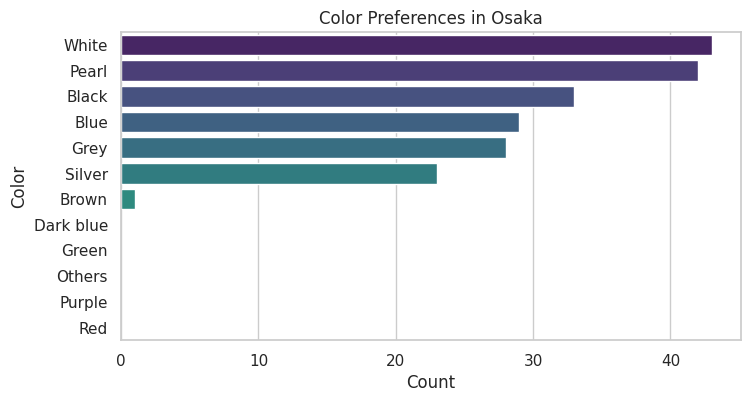

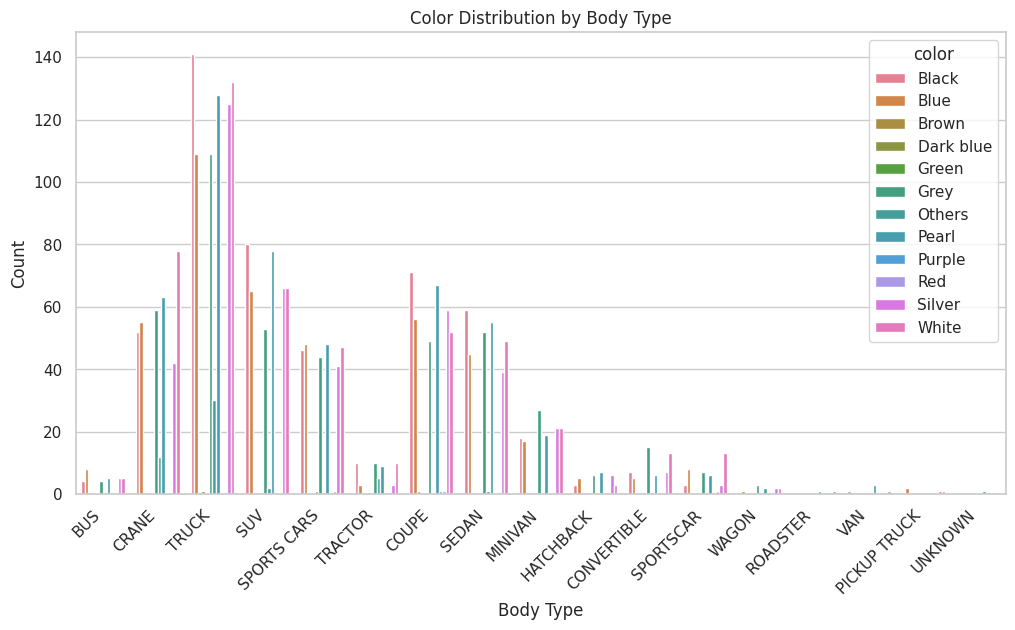

In [ ]:
# prompt: Color and Visual Features
# Most common vehicle colors.
# Average price differences for vehicles of different colors.
# Relationship between vehicle color and mileage.
# Color preferences across different locations.
# Color distribution by body type.

# ... (Your existing code)

# Color Analysis

# 1. Most common vehicle colors
color_counts = data['color'].value_counts()
print("Most common vehicle colors:\n", color_counts)

plt.figure(figsize=(12, 6))
sns.countplot(y='color', data=data, order=color_counts.index, palette="viridis")
plt.title('Most Common Vehicle Colors')
plt.xlabel('Number of Vehicles')
plt.ylabel('Color')
plt.show()


# 2. Average price differences for vehicles of different colors
avg_price_by_color = data.groupby('color')['price'].mean().sort_values(ascending=False)
print("\nAverage price by color:\n", avg_price_by_color)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_by_color.index, y=avg_price_by_color.values, palette="magma")
plt.title('Average Price by Vehicle Color')
plt.xlabel('Color')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()


# 3. Relationship between vehicle color and mileage
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='mileage', data=data)
plt.title('Relationship between Vehicle Color and Mileage')
plt.xlabel('Color')
plt.ylabel('Mileage')
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Color preferences across different locations (Top 5 locations)
top_locations = data['location'].value_counts().nlargest(5).index
for location in top_locations:
    location_data = data[data['location'] == location]
    color_counts_location = location_data['color'].value_counts()
    print(f"\nColor preferences in {location}:\n{color_counts_location}")

    plt.figure(figsize=(8, 4))  # Adjust figure size
    sns.countplot(y='color', data=location_data, order=color_counts_location.index, palette="viridis")
    plt.title(f'Color Preferences in {location}')
    plt.xlabel('Count')
    plt.ylabel('Color')
    plt.show()

#5. Color distribution by body type
plt.figure(figsize=(12, 6))
sns.countplot(x='body_type', hue='color', data=data)
plt.title('Color Distribution by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

Average seats by body type:
 body_type
BUS             36.903226
CONVERTIBLE      4.226415
COUPE            4.067227
CRANE            2.232687
HATCHBACK        4.666667
MINIVAN          6.634146
PICKUP TRUCK     4.750000
ROADSTER         2.000000
SEDAN            4.810000
SPORTS CARS      4.579710
SPORTSCAR        4.512195
SUV              5.382927
TRACTOR          2.000000
TRUCK            2.267442
UNKNOWN          4.000000
VAN              6.600000
WAGON            5.000000
Name: seats, dtype: float64


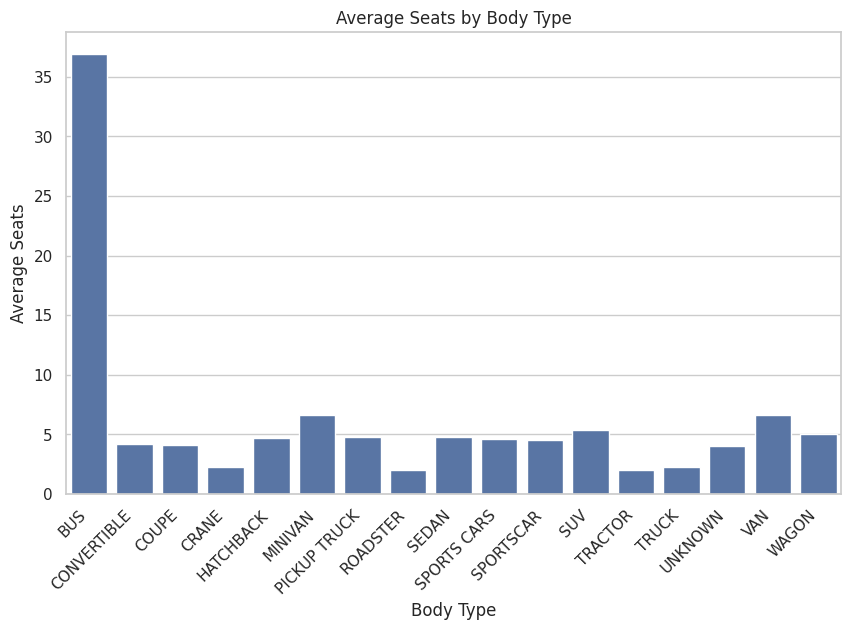

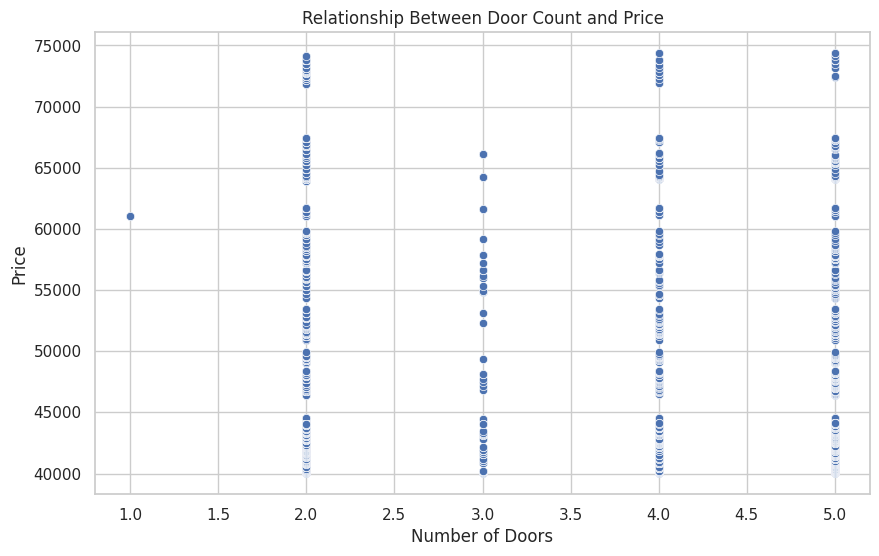


Correlation coefficient between door count and price: -0.20580582352896357

Stock availability by year:
 Year
1973.0      2
1974.0      1
1975.0      1
1977.0      2
1980.0      2
1982.0      2
1983.0      2
1988.0      2
1989.0      2
1991.0      2
1992.0      1
1993.0      2
1994.0      1
1995.0      5
1996.0      4
1997.0      2
1998.0      3
2000.0      1
2001.0      2
2002.0      5
2003.0      7
2004.0      2
2005.0      1
2006.0      4
2007.0     14
2008.0     12
2009.0      4
2010.0      5
2011.0     15
2012.0     18
2013.0     43
2014.0     52
2015.0     51
2016.0     88
2017.0    124
2018.0    175
2019.0    199
2020.0    137
2021.0    268
2022.0    250
2023.0    778
2024.0    533
Name: stock_id, dtype: int64


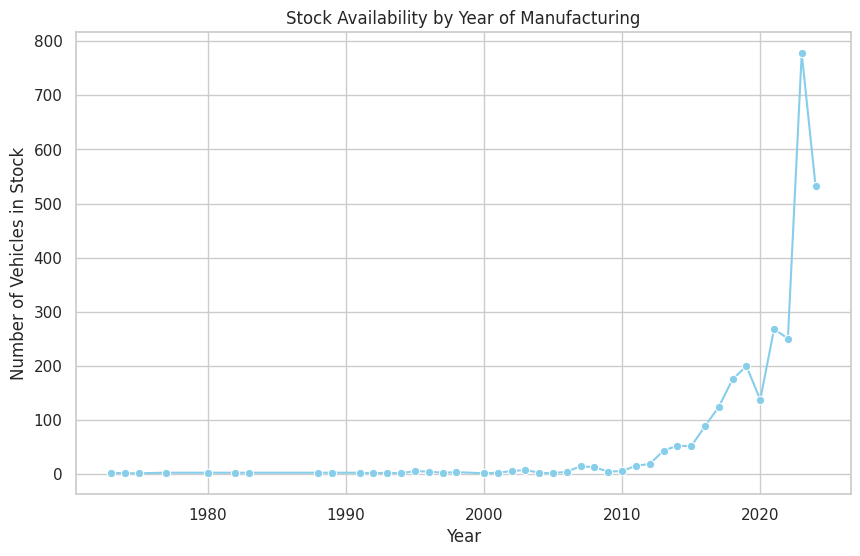


Correlation Matrix of Numerical Variables:
           mileage    engine     price     seats     doors      Year
mileage  1.000000  0.609937  0.003437 -0.022499 -0.303450 -0.319379
engine   0.609937  1.000000  0.287012 -0.194101 -0.595414 -0.192378
price    0.003437  0.287012  1.000000 -0.060786 -0.205806  0.119004
seats   -0.022499 -0.194101 -0.060786  1.000000  0.379539 -0.038172
doors   -0.303450 -0.595414 -0.205806  0.379539  1.000000  0.171406
Year    -0.319379 -0.192378  0.119004 -0.038172  0.171406  1.000000


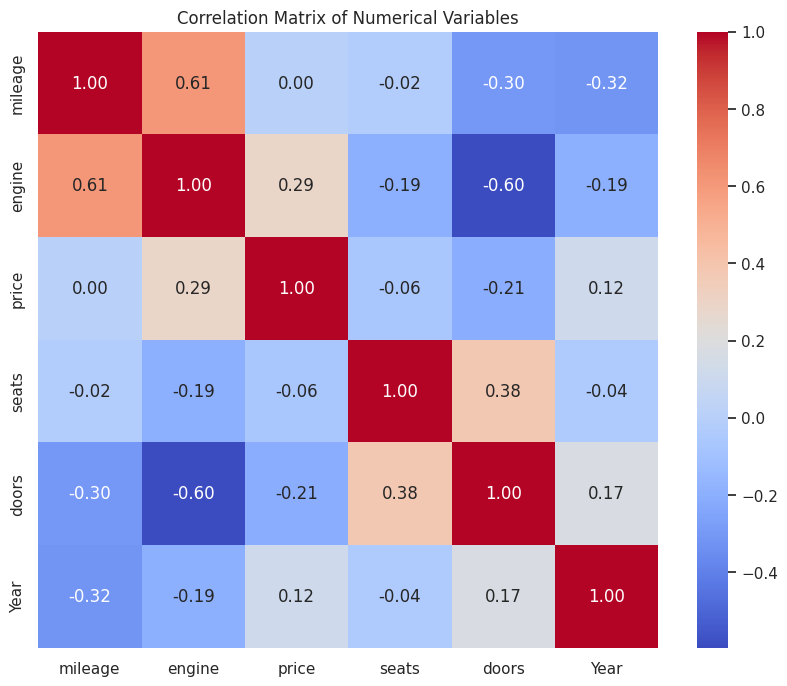

In [ ]:
# prompt: Average seats in vehicles grouped by body type.
# Relationship between door count and price.
# Trends in stock availability by year of manufacturing.
# Correlation analysis across all numerical variables (e.g., mileage, engine, price

# Average seats in vehicles grouped by body type.
average_seats_by_body_type = data.groupby('body_type')['seats'].mean()
print("Average seats by body type:\n", average_seats_by_body_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_seats_by_body_type.index, y=average_seats_by_body_type.values)
plt.title('Average Seats by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Average Seats')
plt.xticks(rotation=45, ha='right')
plt.show()


# Relationship between door count and price.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='doors', y='price', data=data)
plt.title('Relationship Between Door Count and Price')
plt.xlabel('Number of Doors')
plt.ylabel('Price')
plt.show()

# Calculate the correlation coefficient
correlation_coefficient = data['doors'].corr(data['price'])
print(f"\nCorrelation coefficient between door count and price: {correlation_coefficient}")


# Trends in stock availability by year of manufacturing.  (Assuming stock_id represents availability)
stock_by_year = data.groupby('Year')['stock_id'].count()
print("\nStock availability by year:\n", stock_by_year)

plt.figure(figsize=(10, 6))
sns.lineplot(x=stock_by_year.index, y=stock_by_year.values, marker='o', color='skyblue')
plt.title('Stock Availability by Year of Manufacturing')
plt.xlabel('Year')
plt.ylabel('Number of Vehicles in Stock')
plt.show()


# Correlation analysis across all numerical variables
numerical_variables = ['mileage', 'engine', 'price', 'seats', 'doors', 'Year']
correlation_matrix = data[numerical_variables].corr()
print("\nCorrelation Matrix of Numerical Variables:\n", correlation_matrix)


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

(2802, 18)


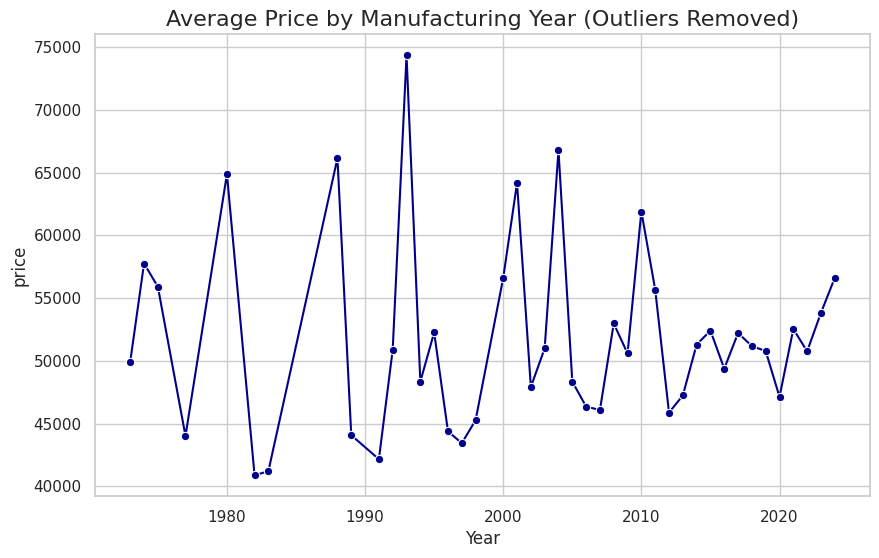

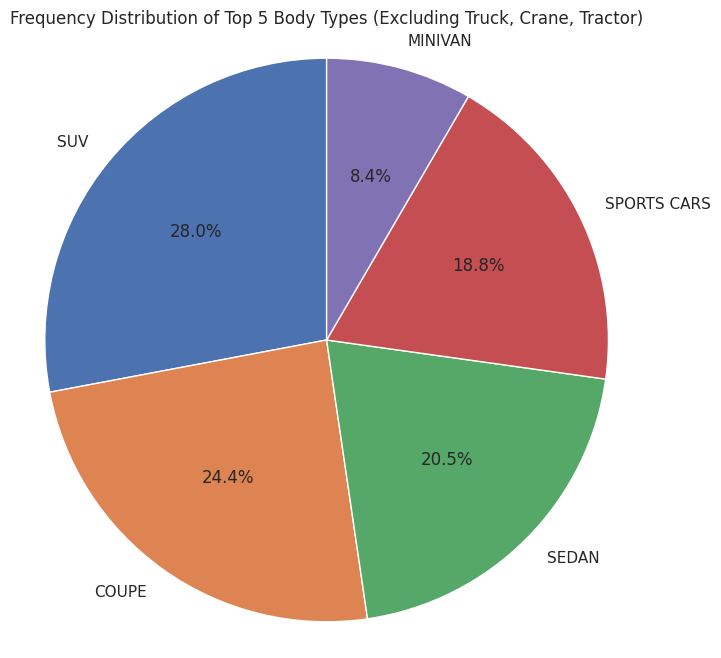

In [ ]:
# prompt: display frequency of  top 5  of body_type on the base of frequency distribution except truck crane tractor make a pie chart

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'data'
# ... (your existing code) ...

# Exclude trucks, cranes, and tractors
excluded_body_types = ['TRUCK', 'CRANE', 'TRACTOR']
filtered_data = data[~data['body_type'].isin(excluded_body_types)]

# Calculate the frequency of body types
body_type_counts = filtered_data['body_type'].value_counts()

# Get the top 5 body types
top_5_body_types = body_type_counts.nlargest(5)

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_5_body_types, labels=top_5_body_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Frequency Distribution of Top 5 Body Types (Excluding Truck, Crane, Tractor)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

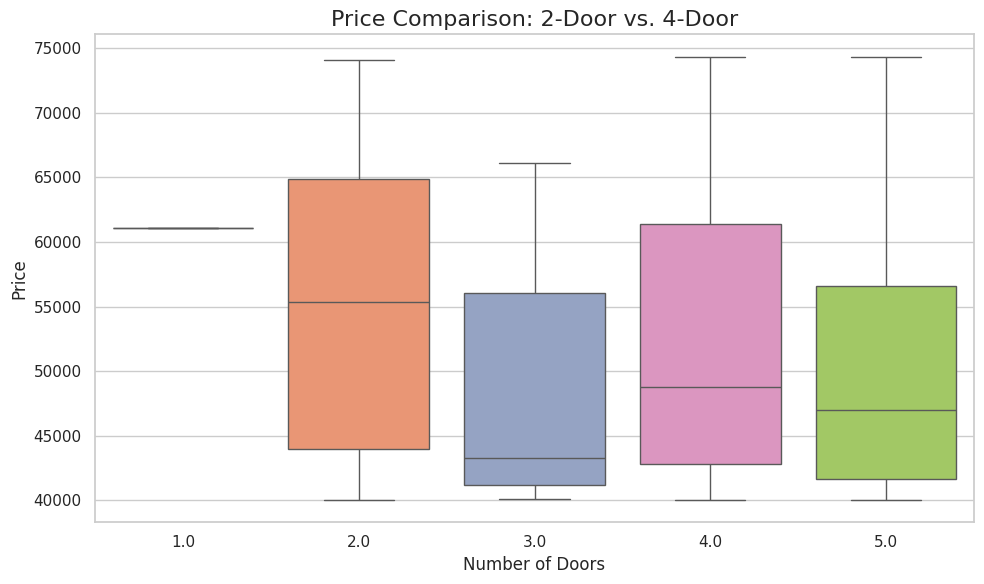

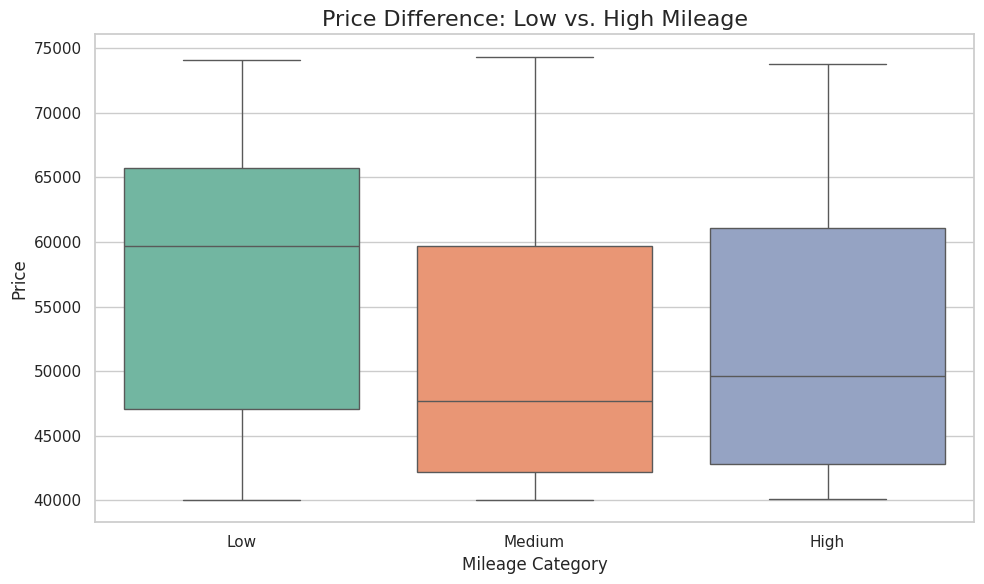

In [ ]:
# prompt: Comparison of average mileage between manual and automatic vehicles.
# Price comparison between 2-door and 4-door vehicles.
# Difference in average price between vehicles with low and high mileage.
# Year-wise comparison of manual vs. automatic transmission distribution.
# Fuel efficiency comparison across brands.

# Comparison of average mileage between manual and automatic vehicles.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='mileage', data=data, palette="Set2")
plt.title('Average Mileage Comparison: Manual vs. Automatic', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Mileage', fontsize=12)
plt.tight_layout()
plt.show()

# Price comparison between 2-door and 4-door vehicles.
plt.figure(figsize=(10, 6))
sns.boxplot(x='doors', y='price', data=data, palette="Set2")
plt.title('Price Comparison: 2-Door vs. 4-Door', fontsize=16)
plt.xlabel('Number of Doors', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

# Difference in average price between vehicles with low and high mileage.
# Define "low" and "high" mileage thresholds (example)
low_mileage_threshold = data['mileage'].quantile(0.25)
high_mileage_threshold = data['mileage'].quantile(0.75)

data['mileage_category'] = 'Medium'
data.loc[data['mileage'] < low_mileage_threshold, 'mileage_category'] = 'Low'
data.loc[data['mileage'] > high_mileage_threshold, 'mileage_category'] = 'High'

plt.figure(figsize=(10, 6))
sns.boxplot(x='mileage_category', y='price', data=data, palette="Set2", order=['Low', 'Medium', 'High'])
plt.title('Price Difference: Low vs. High Mileage', fontsize=16)
plt.xlabel('Mileage Category', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

# Year-wise comparison of manual vs. automatic transmission distribution.
plt.figure(figsize=(15, 6))
sns.countplot(x='Year', hue='transmission', data=data, palette="coolwarm")
plt.title('Transmission Distribution by Year', fontsize=16)
plt.xlabel('Year of Manufacturing', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# Fuel efficiency comparison across brands (assuming mileage represents fuel efficiency).
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='mileage', data=data, palette="pastel")
plt.title('Fuel Efficiency Comparison Across Brands', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Mileage', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

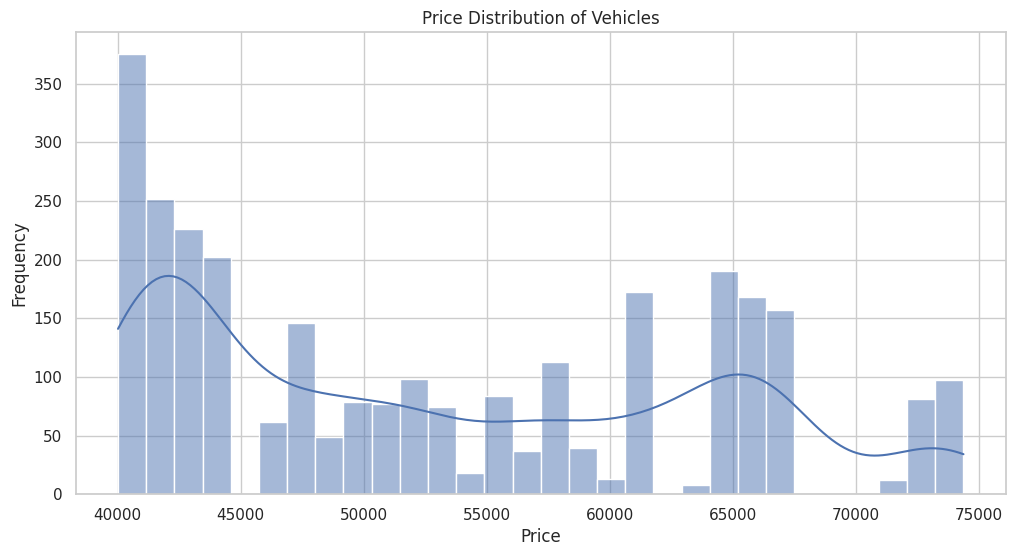

In [ ]:
# prompt: Price Distribution: Frequency of vehicles in different price ranges.

# Price Distribution: Frequency of vehicles in different price ranges.
plt.figure(figsize=(12, 6))
sns.histplot(data['price'], bins=30, kde=True) # kde=True adds a kernel density estimate
plt.title('Price Distribution of Vehicles')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   stock_id          2829 non-null   object  
 1   model_code        2829 non-null   category
 2   Title             2829 non-null   category
 3   Brand             2828 non-null   category
 4   Year              2824 non-null   float64 
 5   engine            2731 non-null   float64 
 6   fuel              2829 non-null   category
 7   transmission      2755 non-null   category
 8   body_type         2829 non-null   object  
 9   mileage           2829 non-null   int64   
 10  color             2829 non-null   category
 11  steering          2829 non-null   category
 12  drive_type        2829 non-null   category
 13  seats             2827 non-null   float64 
 14  doors             2827 non-null   float64 
 15  price             2829 non-null   int64   
 16  location          2829 n